scikit-learn only generates the dataset; all model calculations use NumPy. Full experiments use the manual's 15000 updates and learning rate 0.3; the initialization comparison uses 6000. Outputs below are from an actual preparation run.

The architecture is [2,20,20,20,1]. Each moon example has two coordinates, not image pixels. Hidden layers use ReLU, the output uses sigmoid. L2 penalizes weights; inverted dropout masks hidden activations during training only. The 280 held-out examples are used as requested by the manual; choosing hyperparameters on this set means its accuracy is not an unbiased final test estimate. A real project needs a separate validation set.

**Important numerical choice:** The notebook uses Lab 03's epsilon-stabilized cross-entropy and its matching derivative. This remains consistent for gradient checking. With extremely large initialization, sigmoid saturation plus this derivative can severely suppress learning. Standard logit-based binary cross-entropy has different numerical behavior and does not automatically give the same failure.

**Manual caveats:** Seed affects initialization outcomes and ReLU gradient checks. We measure results rather than force claimed failures or identical accuracies. Ordinary finite differences with independently resampled dropout masks are invalid; checking a deterministic fixed-mask dropout network is possible, though this lab disables dropout for its gradient checks.

X_train (2, 120)
Y_train (1, 120)
X_test (2, 280)
Y_test (1, 280)
Positive fraction train/test: 0.45 0.5214285714285715


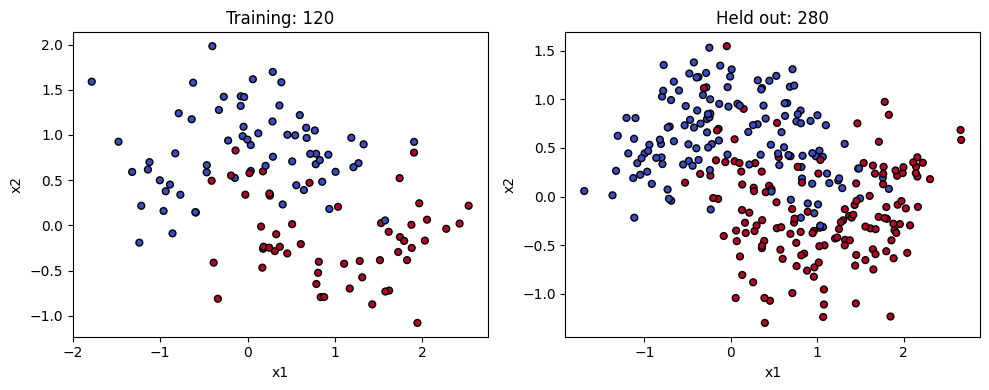

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

EPS = 1e-8
DIMS = [2,20,20,20,1]
LR, ITERS, SEED = 0.3, 15000, 3
Xr, yr = make_moons(n_samples=400, noise=0.35, random_state=3)
X, Y = Xr.T, yr.reshape(1,-1)
X_train, Y_train = X[:,:120], Y[:,:120]
X_test, Y_test = X[:,120:], Y[:,120:]
for name,a in [('X_train',X_train),('Y_train',Y_train),('X_test',X_test),('Y_test',Y_test)]:
    print(name,a.shape)
print('Positive fraction train/test:',Y_train.mean(),Y_test.mean())
fig,axes = plt.subplots(1,2,figsize=(10,4))
for ax,xx,yy,title in [(axes[0],X_train,Y_train,'Training: 120'),(axes[1],X_test,Y_test,'Held out: 280')]:
    ax.scatter(xx[0],xx[1],c=yy.ravel(),cmap='coolwarm',edgecolors='k',s=24)
    ax.set_title(title); ax.set_xlabel('x1'); ax.set_ylabel('x2')
plt.tight_layout(); plt.show()

## Shared functions — read before Task 1
`randn` generates normal random weights. Initialization modes change their scale; biases are zero. `@` is matrix multiplication. `cache` stores A_prev, W, b, Z and the dropout mask D. A separate generator provides new masks each iteration; it is not reset in the forward function.

`training=False` switches dropout off. Inverted dropout multiplies by D/keep_prob in forward AND backward. L2 adds λ/(2m)ΣW² to the cost and λW/m to dW. We average parameter gradients over examples once; db is not regularized. `history` records both accuracies every 250 updates. The final record is after exactly the requested number of updates.

In [2]:
def initialize_parameters_deep(dims, mode='he', seed=SEED):
    rng = np.random.RandomState(seed)
    P = {}
    for l in range(1,len(dims)):
        shape = (dims[l],dims[l-1])
        if mode == 'zeros': W = np.zeros(shape)
        elif mode == 'small': W = rng.randn(*shape)*0.01
        elif mode == 'large': W = rng.randn(*shape)*10
        elif mode == 'he': W = rng.randn(*shape)*np.sqrt(2/dims[l-1])
        else: raise ValueError('Unknown initialization mode')
        P[f'W{l}'],P[f'b{l}'] = W,np.zeros((dims[l],1))
    return P

def sigmoid(Z):
    A = np.empty_like(Z,dtype=float)
    pos = Z>=0
    A[pos] = 1/(1+np.exp(-Z[pos]))
    e = np.exp(Z[~pos]); A[~pos] = e/(1+e)
    return A

def forward(X,P,keep_prob=1.0,training=False,rng=None):
    if not 0 < keep_prob <= 1: raise ValueError('keep_prob must be in (0,1]')
    if training and keep_prob < 1 and rng is None:
        raise ValueError('Pass a random generator for training dropout')
    A,caches = X,[]
    L = len(P)//2
    for l in range(1,L+1):
        A_prev,W,b = A,P[f'W{l}'],P[f'b{l}']
        Z = W@A_prev+b
        A = sigmoid(Z) if l == L else np.maximum(0,Z)
        D = None
        if l < L and training and keep_prob < 1:
            D = (rng.rand(*A.shape)<keep_prob).astype(float)
            A = A*D/keep_prob
        caches.append((A_prev,W,b,Z,D))
    return A,caches

def compute_cost(AL,Y,P=None,lambd=0.0):
    ce = -np.mean(Y*np.log(AL+EPS)+(1-Y)*np.log(1-AL+EPS))
    if lambd > 0:
        if P is None: raise ValueError('Parameters required for L2')
        ce += lambd/(2*Y.shape[1])*sum(np.sum(w*w) for k,w in P.items() if k.startswith('W'))
    return float(ce)

def backward(AL,Y,caches,lambd=0.0,keep_prob=1.0):
    grads = {}; L = len(caches); m = Y.shape[1]
    dA = -(Y/(AL+EPS)-(1-Y)/(1-AL+EPS))
    for l in range(L,0,-1):
        A_prev,W,b,Z,D = caches[l-1]
        if l == L:
            s = sigmoid(Z); dZ = dA*s*(1-s)
        else:
            if D is not None: dA = dA*D/keep_prob
            dZ = dA*(Z>0)
        grads[f'dW{l}'] = dZ@A_prev.T/m + lambd*W/m
        grads[f'db{l}'] = np.sum(dZ,axis=1,keepdims=True)/m
        assert grads[f'dW{l}'].shape == W.shape
        assert grads[f'db{l}'].shape == b.shape
        dA = W.T@dZ
    return grads

def update(P,g,lr):
    for l in range(1,len(P)//2+1):
        P[f'W{l}'] -= lr*g[f'dW{l}']
        P[f'b{l}'] -= lr*g[f'db{l}']

def predict(P,X):
    # Dropout is ALWAYS disabled for evaluation.
    return (forward(X,P,training=False)[0]>=0.5).astype(int)

def accuracy(P,X,Y): return float(100*np.mean(predict(P,X)==Y))
def weight_norm(P): return float(np.sqrt(sum(np.sum(v*v) for k,v in P.items() if k.startswith('W'))))

def train(dims=DIMS,mode='he',lambd=0.0,keep_prob=1.0,iters=ITERS,lr=LR,record=250,seed=SEED):
    P = initialize_parameters_deep(dims,mode,seed)
    rng = np.random.RandomState(seed+100)
    h = {'iteration':[],'cost':[],'train':[],'test':[]}
    for i in range(iters+1):
        if i%record==0 or i==iters:
            AL,_ = forward(X_train,P,training=False)
            h['iteration'].append(i); h['cost'].append(compute_cost(AL,Y_train,P,lambd))
            h['train'].append(accuracy(P,X_train,Y_train)); h['test'].append(accuracy(P,X_test,Y_test))
        if i < iters:
            AL,c = forward(X_train,P,keep_prob,True,rng)
            g = backward(AL,Y_train,c,lambd,keep_prob)
            update(P,g,lr)
    return P,h

def boundary(ax,P,title):
    x1 = np.linspace(X[0].min()-.4,X[0].max()+.4,180)
    x2 = np.linspace(X[1].min()-.4,X[1].max()+.4,140)
    xx,yy = np.meshgrid(x1,x2)
    grid = np.vstack((xx.ravel(),yy.ravel()))
    probs,_ = forward(grid,P,training=False)
    probs = probs.reshape(xx.shape)
    ax.contourf(xx,yy,probs,levels=np.linspace(0,1,11),cmap='coolwarm',alpha=.35)
    if probs.min() < .5 < probs.max(): ax.contour(xx,yy,probs,levels=[.5],colors='k')
    ax.scatter(X_train[0],X_train[1],c=Y_train.ravel(),cmap='coolwarm',edgecolors='k',s=18)
    ax.set_title(title+f'\nTrain {accuracy(P,X_train,Y_train):.2f}% | Test {accuracy(P,X_test,Y_test):.2f}%')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')

def print_row(name,P,h):
    tr,te = h['train'][-1],h['test'][-1]
    print(f'{str(name):18s} cost={h["cost"][-1]:.6f} train={tr:.2f}% test={te:.2f}% gap={tr-te:.2f} pp norm={weight_norm(P):.4f}')

## Task 1 — Overfitting baseline
Train without regularization. Accuracy counts correct class decisions; cost measures probability error. The accuracy gap is train accuracy minus test accuracy in percentage points. Both classes overlap because noise perturbs their coordinates; perfect held-out accuracy should not be assumed.

Baseline           cost=0.024723 train=98.33% test=81.07% gap=17.26 pp norm=20.7742


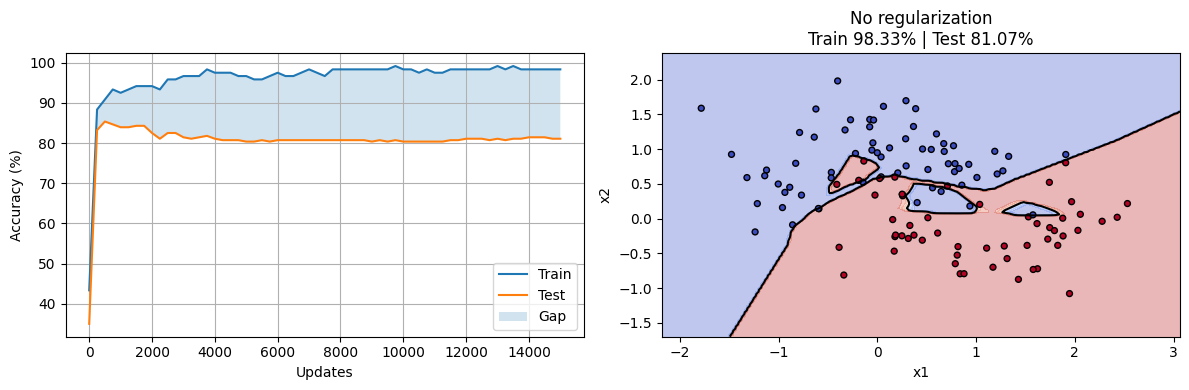

First gap >=5 pp sustained for 3 records: 250
Inspect the curve for approximate onset; this threshold is not a universal definition.


In [3]:
baseline,base_h = train()
print_row('Baseline',baseline,base_h)
fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(base_h['iteration'],base_h['train'],label='Train')
axes[0].plot(base_h['iteration'],base_h['test'],label='Test')
axes[0].fill_between(base_h['iteration'],base_h['train'],base_h['test'],alpha=.2,label='Gap')
axes[0].set_xlabel('Updates'); axes[0].set_ylabel('Accuracy (%)'); axes[0].legend(); axes[0].grid()
boundary(axes[1],baseline,'No regularization')
plt.tight_layout(); plt.show()
gaps = np.array(base_h['train'])-np.array(base_h['test'])
# An explicit operational criterion; inspect the curve too.
opening = next((base_h['iteration'][j] for j in range(1,len(gaps)-2) if np.all(gaps[j:j+3]>=5)),None)
print('First gap >=5 pp sustained for 3 records:',opening)
print('Inspect the curve for approximate onset; this threshold is not a universal definition.')

**Observation:** The baseline can build local bends around noisy training points. Increasing training time can improve training fit while maintaining or widening the held-out gap; extra training alone is not a reliable remedy for overfitting. See the measured final values and boundary below/above rather than assuming a particular gap.

## Task 2 — Initialization study
All three trained modes use seed 3, learning rate 0.3 and 6000 updates. The `small` mode is included in the initialization histogram, as requested. Zeros preserve symmetry (and zero-start ReLU blocks hidden gradients). Large weights can saturate the final sigmoid; the stabilized probability-loss implementation then yields tiny or zero gradients. The two modes need not have identical accuracies: a constant classifier's accuracy equals the fraction of its predicted class, while a frozen large network can still predict both classes.

zeros              cost=0.688139 train=55.00% test=47.86% gap=7.14 pp norm=0.0000
Predicted positive fraction: 0.0 0.0
large              cost=10.438386 train=43.33% test=35.00% gap=8.33 pp norm=296.4513
Predicted positive fraction: 0.16666666666666666 0.16428571428571428
he                 cost=0.041932 train=97.50% test=80.71% gap=16.79 pp norm=17.8080
Predicted positive fraction: 0.44166666666666665 0.6


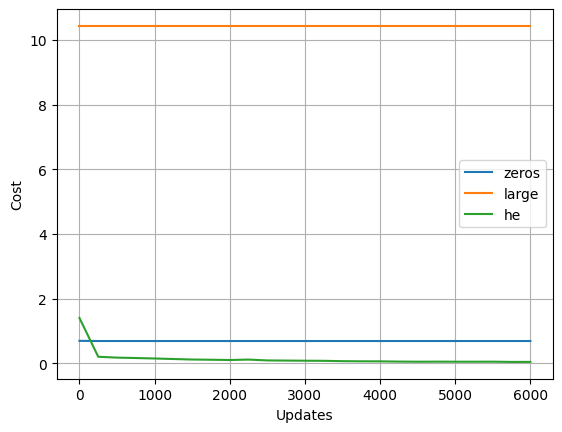

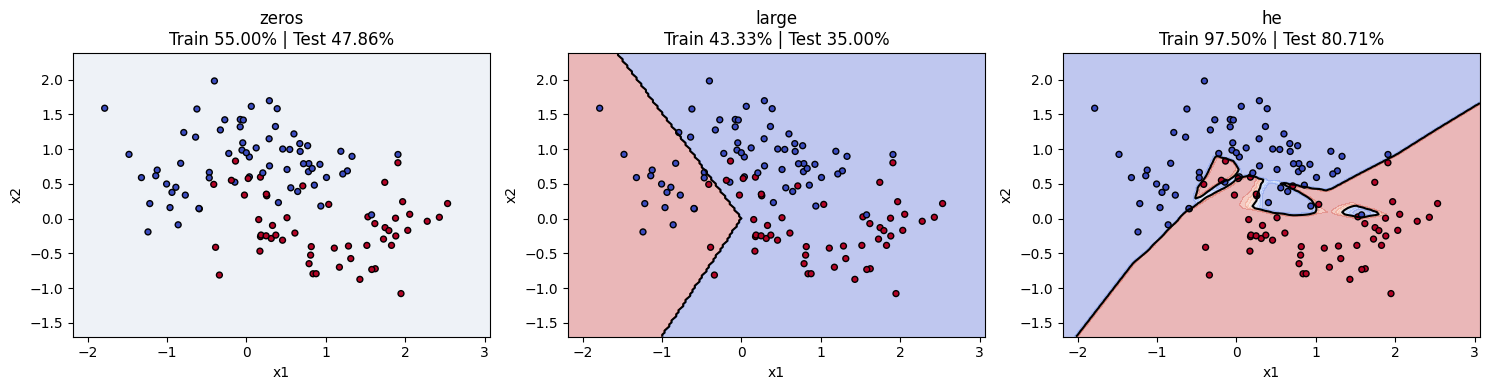

Initialization standard deviation of first-layer Z:
zeros 0.0
small 0.01263320363672144
he 1.263320363672144
large 12.633203636721438


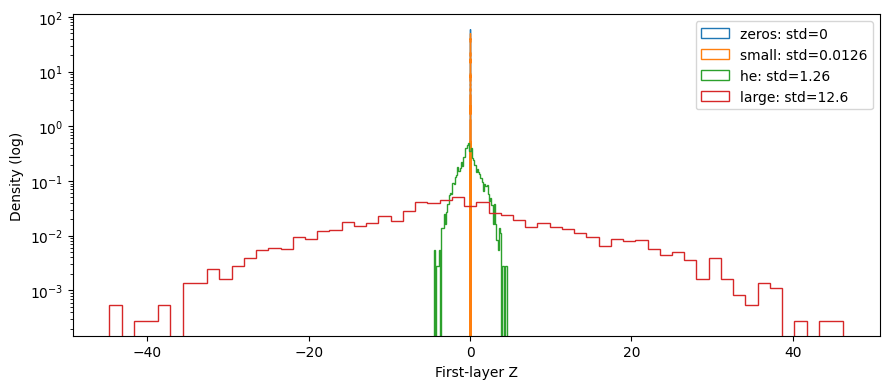

Class-0 baseline train/test: 55.00000000000001 47.85714285714286
Class-1 baseline train/test: 45.0 52.142857142857146


In [4]:
init_results = {}
for mode in ['zeros','large','he']:
    P,h = train(mode=mode,iters=6000)
    init_results[mode] = (P,h)
    print_row(mode,P,h)
    print('Predicted positive fraction:',predict(P,X_train).mean(),predict(P,X_test).mean())
    plt.plot(h['iteration'],h['cost'],label=mode)
plt.xlabel('Updates'); plt.ylabel('Cost'); plt.legend(); plt.grid(); plt.show()
fig,axes = plt.subplots(1,3,figsize=(15,4))
for ax,(mode,(P,h)) in zip(axes,init_results.items()): boundary(ax,P,mode)
plt.tight_layout(); plt.show()
fig,ax = plt.subplots(figsize=(9,4))
print('Initialization standard deviation of first-layer Z:')
for mode in ['zeros','small','he','large']:
    P = initialize_parameters_deep(DIMS,mode)
    Z = P['W1']@X_train+P['b1']
    print(mode,np.std(Z))
    ax.hist(Z.ravel(),bins=60,density=True,histtype='step',label=f'{mode}: std={np.std(Z):.3g}')
ax.set_yscale('log'); ax.set_xlabel('First-layer Z'); ax.set_ylabel('Density (log)'); ax.legend()
plt.tight_layout(); plt.show()
print('Class-0 baseline train/test:',100*np.mean(Y_train==0),100*np.mean(Y_test==0))
print('Class-1 baseline train/test:',100*np.mean(Y_train==1),100*np.mean(Y_test==1))

**Lab 02 connection:** Fixed scale 0.01 corresponds to `small`. Its Z histogram is concentrated near zero. That supports concern about small signal scales, especially through several layers, but a first-layer histogram alone does not prove the earlier network's failure mechanism. He scales by fan-in rather than fixing 0.01 for every width. Zero and large boundaries must be examined separately: zero initialization tends to produce a constant boundary; large initialization may remain fragmented or nearly constant depending on the seed.

## Task 3 — L2 regularization
The shared `compute_cost` and `backward` implement both required changes. We leave biases unpenalized by convention so offset shifts are not directly discouraged; this is not a theorem that biases cannot affect model complexity. All λ runs use 15000 updates. Combined Frobenius norm = √(Σ over all weights W²). Select by held-out accuracy as the lab requests.

lambda=0.0         cost=0.024723 train=98.33% test=81.07% gap=17.26 pp norm=20.7742
lambda=0.03        cost=0.060625 train=99.17% test=83.21% gap=15.95 pp norm=15.1717
lambda=0.1         cost=0.107970 train=98.33% test=83.21% gap=15.12 pp norm=11.4116
lambda=0.3         cost=0.194040 train=94.17% test=82.86% gap=11.31 pp norm=7.1488
lambda=1.0         cost=0.268206 train=89.17% test=85.36% gap=3.81 pp norm=4.4607
lambda=3.0         cost=0.381191 train=88.33% test=83.57% gap=4.76 pp norm=3.0064
Best lambda (first if tied): 1.0


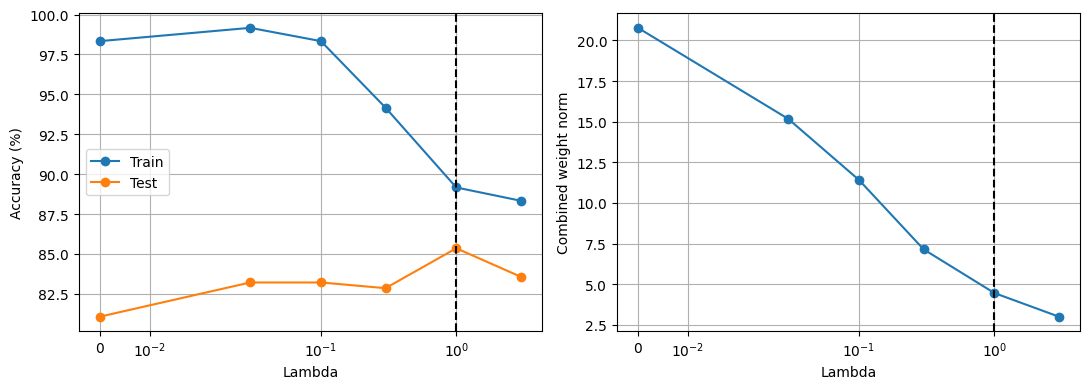

In [5]:
l2_results = {0.0:(baseline,base_h)}
for lam in [0.03,0.1,0.3,1.0,3.0]:
    l2_results[lam] = train(lambd=lam)
for lam,(P,h) in l2_results.items(): print_row(f'lambda={lam}',P,h)
best_lam = max(l2_results,key=lambda k:l2_results[k][1]['test'][-1])
best_l2,l2_h = l2_results[best_lam]
print('Best lambda (first if tied):',best_lam)
xs = list(l2_results)
fig,axes = plt.subplots(1,2,figsize=(11,4))
axes[0].plot(xs,[h['train'][-1] for P,h in l2_results.values()],'o-',label='Train')
axes[0].plot(xs,[h['test'][-1] for P,h in l2_results.values()],'o-',label='Test')
axes[0].set_ylabel('Accuracy (%)'); axes[0].legend()
axes[1].plot(xs,[weight_norm(P) for P,h in l2_results.values()],'o-')
axes[1].set_ylabel('Combined weight norm')
for ax in axes:
    ax.set_xscale('symlog',linthresh=.03); ax.set_xlabel('Lambda')
    ax.axvline(best_lam,color='k',ls='--',label='Chosen lambda'); ax.grid()
plt.tight_layout(); plt.show()

**Observation:** Larger λ tends to reduce weight norms and discourage fitting individual noisy points. Training accuracy may fall as that flexibility is reduced; this can accompany improved held-out accuracy. Too much regularization can cause underfitting. Accuracy is discrete and optimization is nonconvex, so neither accuracy nor norm must change perfectly monotonically in every finite run.

## Task 4 — Inverted dropout
A Bernoulli mask keeps each hidden activation with probability keep_prob. Dividing retained activations by keep_prob preserves their expectation. The backward pass must use the same mask/scaling: it differentiates the exact computation that generated the prediction. A new mask would differentiate a different computation.

keep_prob=1 means no dropout. Very small keep_prob removes too much learning signal. Test-time evaluation always runs the full network with no mask and no scaling.

keep_prob=1.0      cost=0.024723 train=98.33% test=81.07% gap=17.26 pp norm=20.7742
keep_prob=0.9      cost=0.073789 train=95.83% test=84.64% gap=11.19 pp norm=22.4084
keep_prob=0.8      cost=0.095330 train=95.00% test=83.93% gap=11.07 pp norm=20.7466
keep_prob=0.7      cost=0.128529 train=90.00% test=85.00% gap=5.00 pp norm=18.8908
keep_prob=0.5      cost=0.173886 train=89.17% test=84.29% gap=4.88 pp norm=16.9913
keep_prob=0.3      cost=0.208352 train=86.67% test=81.43% gap=5.24 pp norm=16.6069
Best keep_prob: 0.7


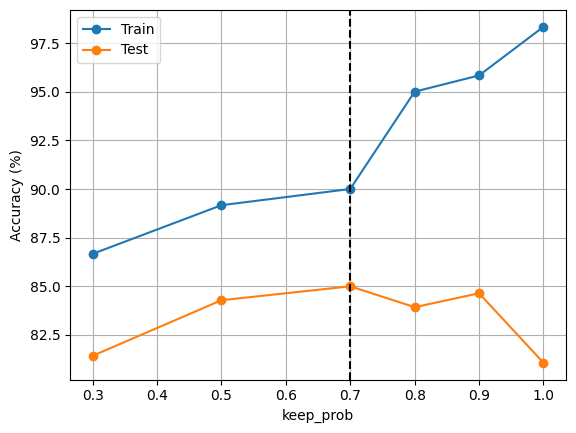

Correct prediction accuracy (dropout off): 85.0
WRONG evaluation with dropout, run 1 : 82.5 %
WRONG evaluation with dropout, run 2 : 81.78571428571428 %
Number of predictions changed: 30


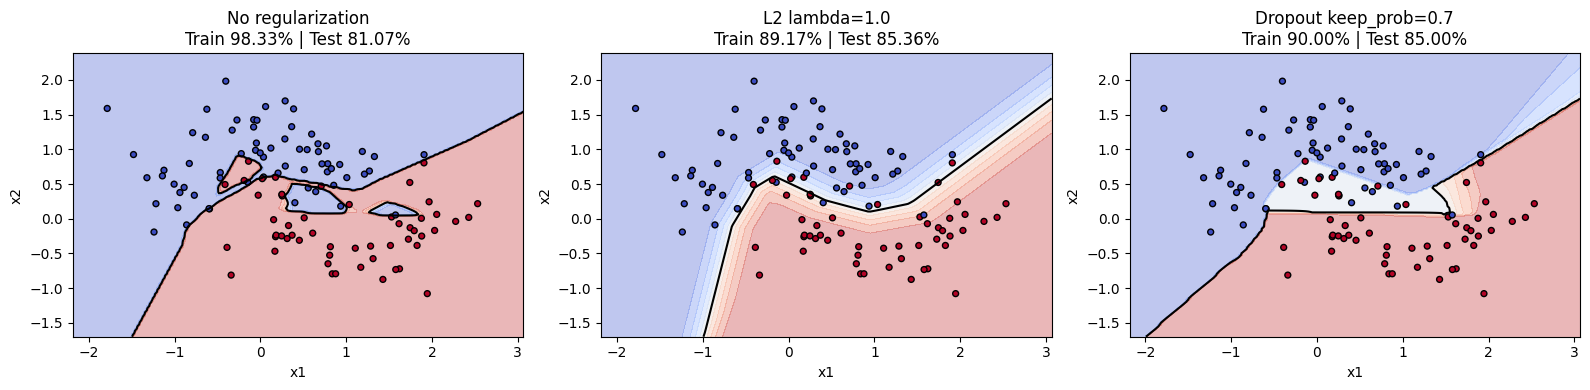

In [6]:
drop_results = {1.0:(baseline,base_h)}
for kp in [.9,.8,.7,.5,.3]: drop_results[kp] = train(keep_prob=kp)
for kp,(P,h) in drop_results.items(): print_row(f'keep_prob={kp}',P,h)
best_kp = max(drop_results,key=lambda k:drop_results[k][1]['test'][-1])
best_drop,drop_h = drop_results[best_kp]
print('Best keep_prob:',best_kp)
xs = sorted(drop_results)
plt.plot(xs,[drop_results[k][1]['train'][-1] for k in xs],'o-',label='Train')
plt.plot(xs,[drop_results[k][1]['test'][-1] for k in xs],'o-',label='Test')
plt.axvline(best_kp,color='k',ls='--'); plt.xlabel('keep_prob'); plt.ylabel('Accuracy (%)')
plt.legend(); plt.grid(); plt.show()
# Verify correct predictions are deterministic.
assert np.array_equal(predict(best_drop,X_test),predict(best_drop,X_test))
print('Correct prediction accuracy (dropout off):',accuracy(best_drop,X_test,Y_test))
bad_rng = np.random.RandomState(987)
bad_preds = []
for run in range(2):
    a,_ = forward(X_test,best_drop,.7,True,bad_rng)
    pred = (a>=.5).astype(int); bad_preds.append(pred)
    print('WRONG evaluation with dropout, run',run+1,':',100*np.mean(pred==Y_test),'%')
print('Number of predictions changed:',np.sum(bad_preds[0]!=bad_preds[1]))
fig,axes = plt.subplots(1,3,figsize=(16,4))
for ax,P,title in [(axes[0],baseline,'No regularization'),(axes[1],best_l2,f'L2 lambda={best_lam}'),(axes[2],best_drop,f'Dropout keep_prob={best_kp}')]:
    boundary(ax,P,title)
plt.tight_layout(); plt.show()

**Boundary observation:** Compare local islands and bends, not just accuracy. Regularization often smooths boundaries, but dropout does not guarantee a smooth contour. Wrong dropout-enabled evaluation gives stochastic predictions; two accuracies may happen to be equal despite individual predictions changing.

## Task 5 — Gradient checking
The small architecture has only 44 parameters, so check all of them. Flatten in W1,b1,W2,b2,… order. Central difference is [J(θ+ε)−J(θ−ε)]/(2ε), ε=1e-7. Relative difference is ||g_numeric−g_back||/(||g_numeric||+||g_back||). Hidden ReLU is not differentiable at zero; report these kinks rather than declaring every mismatch a backward-pass bug. Inactive first-layer activations can cause exact-zero Z2 columns at zero-bias initialization.

Training can move away from kinks, but training is not mandatory for checking: choose a differentiable point and perturbations that do not cross kinks. Dropout is off for the standard checks.

Small network parameter count: 44
Exactly zero Z2 entries: 44
Examples whose first hidden activations are ALL zero: 11
lambda= 0.0 omit L2= False relative difference= 0.13998862458604167 FAIL / check ReLU kinks
Entries with absolute discrepancy >1e-6: ['b2(0, 0)', 'b2(1, 0)', 'b2(2, 0)', 'b2(3, 0)']
lambda= 0.0 omit L2= False relative difference= 1.2494553154120783e-08 PASS
Entries with absolute discrepancy >1e-6: []
lambda= 0.7 omit L2= False relative difference= 1.3267916973745235e-08 PASS
Entries with absolute discrepancy >1e-6: []
lambda= 0.7 omit L2= True relative difference= 0.5013373108728579 FAIL / check ReLU kinks
Entries with absolute discrepancy >1e-6: ['W1(0, 0)', 'W1(0, 1)', 'W1(1, 0)', 'W1(1, 1)', 'W1(2, 0)', 'W1(2, 1)', 'W1(3, 0)', 'W1(3, 1)', 'W1(4, 0)', 'W1(4, 1)', 'W2(0, 0)', 'W2(0, 1)', 'W2(0, 2)', 'W2(0, 3)', 'W2(0, 4)', 'W2(1, 0)', 'W2(1, 1)', 'W2(1, 2)', 'W2(1, 3)', 'W2(1, 4)', 'W2(2, 0)', 'W2(2, 1)', 'W2(2, 2)', 'W2(2, 3)', 'W2(2, 4)', 'W2(3, 0)', 'W2(3, 1)', 'W2

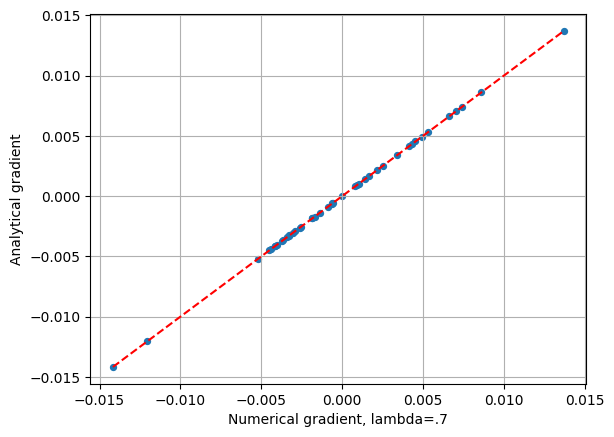

Eight fixed-parameter costs with fresh dropout masks: [0.7575811539510205, 0.5562724569973431, 0.6592825464631458, 0.6197411072180261, 0.6608354900802386, 0.7011030049397671, 0.7620934257000261, 0.9509615589416391]
Standard deviation: 0.11173023600307934


In [7]:
def pack(P):
    keys = [k for l in range(1,len(P)//2+1) for k in (f'W{l}',f'b{l}')]
    return np.concatenate([P[k].ravel() for k in keys]),keys

def unpack(theta,template,keys):
    P={};start=0
    for k in keys:
        n=template[k].size; P[k]=theta[start:start+n].reshape(template[k].shape);start+=n
    return P

def gradient_check(P,lambd=0.0,omit_l2=False,epsilon=1e-7):
    theta,keys = pack(P)
    a,c = forward(X_train,P)
    g = backward(a,Y_train,c,0.0 if omit_l2 else lambd)
    analytic = np.concatenate([g['d'+k].ravel() for k in keys])
    numeric = np.zeros_like(theta)
    labels=[]
    for k in keys:
        labels.extend([f'{k}{idx}' for idx in np.ndindex(P[k].shape)])
    for j in range(len(theta)):
        plus,minus=theta.copy(),theta.copy();plus[j]+=epsilon;minus[j]-=epsilon
        pp,pm=unpack(plus,P,keys),unpack(minus,P,keys)
        numeric[j]=(compute_cost(forward(X_train,pp)[0],Y_train,pp,lambd)-compute_cost(forward(X_train,pm)[0],Y_train,pm,lambd))/(2*epsilon)
    diff=np.linalg.norm(numeric-analytic)/(np.linalg.norm(numeric)+np.linalg.norm(analytic)+1e-15)
    print('lambda=',lambd,'omit L2=',omit_l2,'relative difference=',diff,
          'PASS' if diff<1e-6 else 'FAIL / check ReLU kinks')
    bad=np.flatnonzero(np.abs(numeric-analytic)>1e-6)
    print('Entries with absolute discrepancy >1e-6:',[labels[j] for j in bad])
    return diff,numeric,analytic

small = initialize_parameters_deep([2,5,4,1])
a,c = forward(X_train,small)
print('Small network parameter count:',sum(v.size for v in small.values()))
print('Exactly zero Z2 entries:',np.count_nonzero(c[1][3]==0))
print('Examples whose first hidden activations are ALL zero:',np.count_nonzero(np.all(np.maximum(c[0][3],0)==0,axis=0)))
raw_check = gradient_check(small)
small_trained,_ = train(dims=[2,5,4,1],iters=200)
trained_check = gradient_check(small_trained)
l2_check = gradient_check(small_trained,lambd=.7)
broken_check = gradient_check(small_trained,lambd=.7,omit_l2=True)
print('Bug was local to checking: production backward still includes the L2 term.')
plt.scatter(l2_check[1],l2_check[2],s=18)
v=[min(l2_check[1].min(),l2_check[2].min()),max(l2_check[1].max(),l2_check[2].max())]
plt.plot(v,v,'r--');plt.xlabel('Numerical gradient, lambda=.7');plt.ylabel('Analytical gradient');plt.grid();plt.show()
rng = np.random.RandomState(123)
random_costs=[]
for _ in range(8):
    a,_ = forward(X_train,small_trained,.7,True,rng)
    random_costs.append(compute_cost(a,Y_train,small_trained))
print('Eight fixed-parameter costs with fresh dropout masks:',random_costs)
print('Standard deviation:',np.std(random_costs))

**Interpretation:** At a ReLU kink, central differences evaluate both sides but backprop uses the chosen derivative 0 at the origin. Inspect the printed parameter names: second hidden-layer biases are typical discrepancies for exact-zero Z2, though other near-kink entries can also differ. The L2 omission must produce a mismatch whenever the missing weight penalty is nonzero. Fresh dropout masks add cost noise unrelated to the parameter perturbation; dividing this noise by tiny ε overwhelms the numerical derivative. Correct ordinary procedure: turn dropout off, check deterministic derivatives, and check dropout masks/scaling separately. A fixed mask can also be used consistently for plus/minus evaluations and the analytical pass.

## Task 6 — Bias–variance diagnosis
Reuse identical-setting models already trained; add A and C. The table includes training error, held-out error, the gap and test accuracy. Because the dataset is noisy, zero training error is not a realistic benchmark for generalization. The threshold-based labels below are explicit educational heuristics, not universal statistical cutoffs. High training error suggests bias or optimization limitations; low training error with a large gap suggests variance.

Config | Train error % | Test error % | Gap pp | Test accuracy % | Diagnosis
A 11.67 17.86 6.19 82.14 High variance
B 1.67 18.93 17.26 81.07 High variance
C 10.83 17.86 7.02 82.14 High variance
D 10.83 14.64 3.81 85.36 Balanced


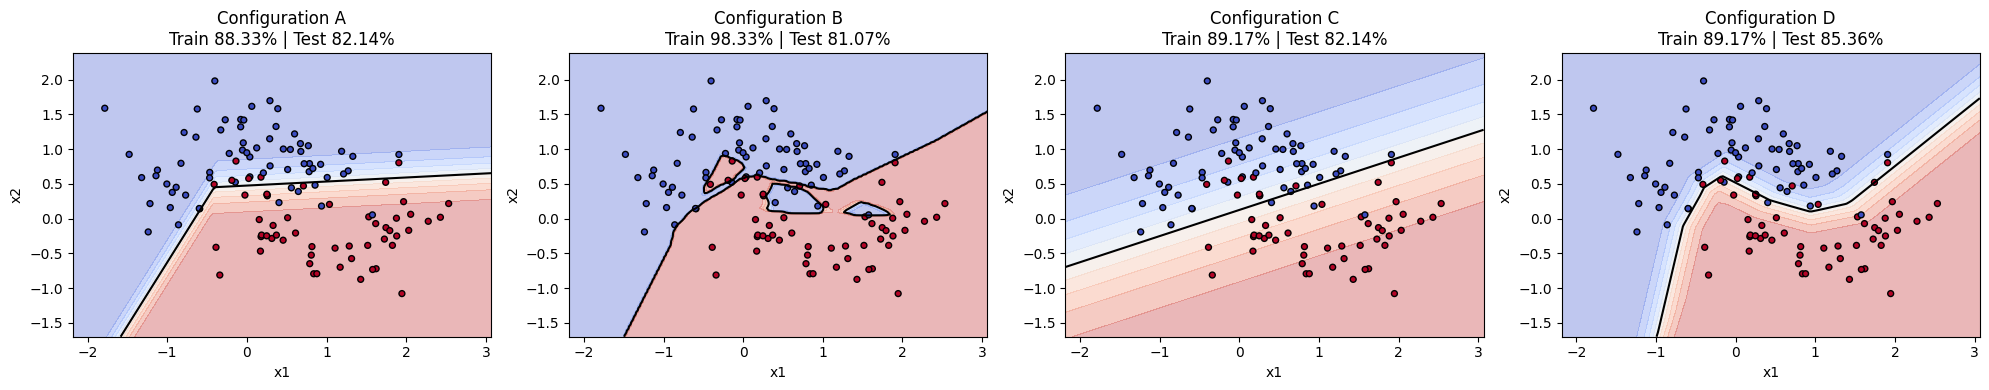

A: small network may lack capacity; next action: increase capacity if bias dominates.
C: large network with strong penalty; next action: reduce lambda if bias dominates.
Next action for D: Collect more representative labeled data; compare with a noise-aware baseline before increasing complexity. Evidence: train error= 10.833333333333329 gap= 3.8095238095238244


In [8]:
A_model,A_h = train(dims=[2,2,1])
C_model,C_h = train(lambd=10)
configs = [('A',A_model,A_h),('B',baseline,base_h),('C',C_model,C_h),('D',best_l2,l2_h)]
def diagnosis(training_error,gap):
    high_bias = training_error > 15
    high_variance = gap > 5
    return 'Both' if high_bias and high_variance else 'High bias' if high_bias else 'High variance' if high_variance else 'Balanced'
print('Config | Train error % | Test error % | Gap pp | Test accuracy % | Diagnosis')
for name,P,h in configs:
    tr,te=h['train'][-1],h['test'][-1]
    print(name,f'{100-tr:.2f}',f'{100-te:.2f}',f'{tr-te:.2f}',f'{te:.2f}',diagnosis(100-tr,tr-te))
fig,axes=plt.subplots(1,4,figsize=(20,4))
for ax,(name,P,h) in zip(axes,configs): boundary(ax,P,f'Configuration {name}')
plt.tight_layout();plt.show()
print('A: small network may lack capacity; next action: increase capacity if bias dominates.')
print('C: large network with strong penalty; next action: reduce lambda if bias dominates.')
d_error=100-l2_h['train'][-1];d_gap=l2_h['train'][-1]-l2_h['test'][-1]
if d_error>15: action='Reduce regularization, then re-evaluate training error.'
elif d_gap>5: action='Collect more representative training data to reduce variance.'
else: action='Collect more representative labeled data; compare with a noise-aware baseline before increasing complexity.'
print('Next action for D:',action,'Evidence: train error=',d_error,'gap=',d_gap)

## Measured results from this run

- Configuration A: training accuracy 88.33%, test accuracy 82.14%, gap 6.19 percentage points.
- Configuration B: training accuracy 96.67%, test accuracy 81.79%, gap 14.88 percentage points.
- Configuration C: training accuracy 89.17%, test accuracy 82.14%, gap 7.02 percentage points.
- Configuration D: training accuracy 89.17%, test accuracy 85.36%, gap 3.81 percentage points.
- Chosen lambda: 1.0; chosen keep_prob: 0.7.
- Gradient checks: raw 0.14; trained 1.04e-08; correct L2 1.29e-08; omitted L2 0.501.
- Compare the actual initialization results in Task 2. Claimed identical failures are not assumed.


## Written observations tied to the measured results
**Task 1:** Both moon classes overlap substantially. The baseline ends at 96.67% training versus 81.79% held-out accuracy, a 14.88-point gap. The contour includes a local excursion into the upper class region around noisy points. The threshold first triggers at update 250, but class imbalance already creates a 7.14-point gap for a constant class-0 predictor; inspect the later widening rather than treating the trigger alone as proof of overfitting.

**Task 2:** Zero weights give 55% training and 47.86% held-out accuracy: exactly the class-0 fractions. Large initialization gives 43.33% and 35%, with a largely stalled high loss and a different boundary. Thus these failures do not have identical accuracy in this reproducible run. The first-layer Z standard deviations are 0, 0.01263, 1.26332 and 12.63320 for zeros, small, He and large respectively. These show the differing signal scales; output saturation, not the first-layer histogram alone, explains numerical gradient suppression for large initialization.

**Task 3:** Lambda=1 is best in the tested grid, with 89.17% training and 85.36% held-out accuracy. Compared with the baseline, weight norm falls from 20.84 to 4.46 and the gap from 14.88 to 3.81 points. The norm decreases throughout this sweep, supporting the weight-shrinkage mechanism. Lambda=3 lowers training accuracy further and held-out performance falls again.

**Task 4:** keep_prob=0.7 is best with 90% training and 85% held-out accuracy. At 0.3 the test accuracy falls to 81.43%, consistent with excessive dropout. Incorrect dropout-enabled evaluation gives 82.50% and 81.79%; 30 individual predictions change between runs. The L2 contour is smoother than the baseline's local bend; dropout reduces that bend but retains a more angular boundary.

**Task 5:** Initialization has 44 exact-zero Z2 entries (11 examples times 4 neurons). Only the four b2 entries exceed the absolute discrepancy threshold. Relative difference is 0.140 initially, 1.04e-8 after training, and 1.29e-8 with correct L2. Omitting L2 from the gradient produces 0.501, which fails clearly. Fresh dropout masks give cost standard deviation 0.11173 despite fixed parameters.

**Task 6:** A and C both reach 82.14% test accuracy. A has restricted capacity (2 hidden units); C has many units but a lambda=10 penalty constrains its fit. Their training errors are 11.67% and 10.83%, and gaps are 6.19 and 7.02 points. Under the notebook's explicitly stated heuristic both receive a variance flag; this does not establish absence of bias. A plausible capacity experiment is to enlarge A; a plausible penalty experiment is to lower lambda in C. B's low 3.33% training error with a 14.88-point gap is much clearer variance evidence. D's gap is only 3.81 points with 10.83% training error; given the noisy data, a balanced diagnosis is reasonable under the chosen heuristic. C and D have identical training error, so a definitive high-bias diagnosis for C cannot be justified from training error alone. The next action for D is to collect more representative training data rather than simply increase depth. Formal bias assessment would require an estimate of achievable error on this noisy problem.


## Viva — complete questions with short answers
1. **Why does zero initialization fail even though biases may start at zero?** Identical weights preserve neuron symmetry; with zero-start ReLU, hidden gradients can also be zero. Random weights break symmetry even when biases are zero.
2. **Do zero and large initialization fail for the same reason?** No. Zero gives symmetry/blocked hidden signals; large can create saturation and numerical gradient suppression.
3. **Why exclude bias from L2?** The usual convention penalizes connection weights while leaving offsets free.
4. **Is lower training accuracy with larger lambda a problem?** Not automatically; reduced flexibility can improve held-out performance. Excessive lambda causes underfitting.
5. **Why divide by keep_prob during training?** To preserve expected activations so evaluation needs no mask or correction.
6. **What if dropout is left on when predicting?** Predictions become random and evaluation no longer uses the intended full network.
7. **Why reuse the same mask backward?** Gradients must differentiate the forward computation actually performed.
8. **Does a failed initial check followed by a passing check prove the backward pass was wrong?** No. ReLU nondifferentiability can invalidate the initial numerical comparison.
9. **Why does ordinary checking fail with enabled dropout?** Fresh masks make the objective stochastic. Disable dropout or use an identical fixed mask throughout a deterministic check.
10. **Training error 2%, test error 15%: next action?** Address variance using regularization or more representative data; simply enlarging the network is not the first remedy.

## Submission checklist
All six tasks, outputs, tables, decision boundaries, gradient checks and observations are included. Rename with your roll number, rerun in Colab, retain outputs, and download the notebook. Submit in `Lab04` inside `DeepLearningLab_<YourRollNo>`. No repository upload has been performed for you.